<a href="https://colab.research.google.com/github/moridin04/CCDATSCL_COM221ML_EXERCISES/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5

In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [2]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [3]:
df_exam_scores['Method'].value_counts()

,count
Method,
A,17
B,17
C,16


Compute the mean and standard deviation of exam scores for each group.

In [4]:
df_exam_scores.groupby('Method').agg(['mean', 'std'])

StudentID                Score          
            mean       std       mean       std
Method                                         
A            9.0  5.049752  78.588235  2.575336
B           26.0  5.049752  86.294118  2.365500
C           42.5  4.760952  71.937500  1.768945

Use a plot to show the exam scores by teaching method.

/tmp/ipython-input-2108813404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_exam_scores, x='Method', y='Score', palette='viridis')


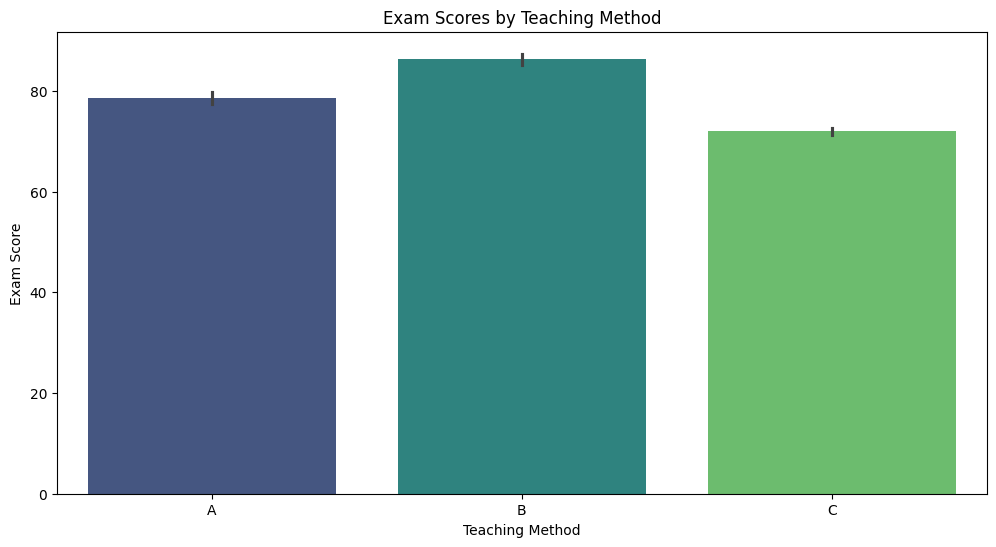

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_exam_scores, x='Method', y='Score', palette='viridis')
plt.title('Exam Scores by Teaching Method')
plt.xlabel('Teaching Method')
plt.ylabel('Exam Score')
plt.show()

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [13]:
A = df_exam_scores[df_exam_scores['Method'] == 'A']['Score']
B = df_exam_scores[df_exam_scores['Method'] == 'B']['Score']
C = df_exam_scores[df_exam_scores['Method'] == 'C']['Score']

f_statistic, p_value = stats.f_oneway(A, B, C)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05

F-statistic: 165.1785
P-value: 0.0000


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [12]:
if p_value < alpha:
    print("Significant difference found (Reject H0)")
else:
    print("No significant difference found (Fail to reject H0)")

Significant difference found (Reject H0)


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [14]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [16]:
df_littering_data.groupby('Gender').size()

,0
Gender,
Female,20
Male,20


In [17]:
df_littering_data.groupby('Litter').size()

,0
Litter,
No,22
Yes,18


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [18]:
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'], margins=True)
contingency_table

Litter,No,Yes,All
Gender,,,
Female,14,6,20
Male,8,12,20
All,22,18,40


In [20]:
print("Row Totals:")
print(contingency_table.loc[['Female', 'Male'], 'All'])
print("\nColumn Totals:")
print(contingency_table.loc['All', ['No', 'Yes']])
print("\nGrand Total:")
print(contingency_table.loc['All', 'All'])

Row Totals:
Gender
Female    20
Male      20
Name: All, dtype: int64

Column Totals:
Litter
No     22
Yes    18
Name: All, dtype: int64

Grand Total:
40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

Null Hypothesis (H₀): There is no association between gender and littering behavior.
Gender and littering behavior are independent.

Alternative Hypothesis (H₁): There is an association between gender and littering behavior.
Gender and littering behavior are not independent.

Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

In [22]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2}")
print(f"P-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies table:")
print(expected)


Chi-square statistic: 3.6363636363636367
P-value: 0.45744899514884474
Degrees of freedom: 4
Expected frequencies table:
[[11.  9. 20.]
 [11.  9. 20.]
 [22. 18. 40.]]


Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [23]:
alpha = 0.05
if p_value < alpha:
    print("Significant difference found (Reject H0)")
else:
    print("No significant difference found (Fail to reject H0)")

No significant difference found (Fail to reject H0)


Interpret your results. Is there evidence that gender and littering behavior are associated?

There is no evidence that gender and littering behavior are associated.
